## 1. Setup and Financial Valuation Framework

In [12]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# --- 1. System & Reproducibility Settings ---
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
tf.get_logger().setLevel('ERROR')

np.random.seed(42)
tf.random.set_seed(42)

# --- 2. Financial Configuration (Solvency II) ---
risk_free_rate = 0.02  
valuation_age = 65
max_age = 95
time_horizon = max_age - valuation_age

# --- 3. Actuarial Functions ---
def get_discount_factors(rate, horizon):
    """Compute present value discount factors."""
    t = np.arange(1, horizon + 1)
    return np.exp(-rate * t)

def calculate_tp_x(mx_path):
    """Calculate survival probabilities from death rates."""
    px = np.exp(-mx_path)
    tp_x = np.concatenate(([1.0], np.cumprod(px)))
    return tp_x

def compute_annuity_pv(tp_x, discount_factors):
    """Compute the Present Value of a life annuity."""
    return np.sum(tp_x[1:] * discount_factors[:len(tp_x)-1])

def create_sequences(data, window_size):
    """Create sliding window sequences for LSTM training."""
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), 0])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

print(f"Setup complete. Valuation Age: {valuation_age} | Discount Rate: {risk_free_rate*100}%")

Setup complete. Valuation Age: 65 | Discount Rate: 2.0%


## 2. Data Loading and Lee-Carter Parameter Extraction

In [13]:
def load_hmd_mx(filepath):
    df = pd.read_csv(filepath, skiprows=2, sep='\s+')
    df['Age'] = df['Age'].astype(str).str.replace('+', '', regex=False).astype(int)
    for col in ['Female', 'Male', 'Total']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df.dropna(subset=['Total'])

# Load and prepare log_mx matrix
df = load_hmd_mx('../data/Mx_1x1.txt')
df_clean = df[(df['Year'] >= 1950) & (df['Age'] <= 95)].copy()
mx_matrix = df_clean.pivot(index='Age', columns='Year', values='Total').replace(0, 1e-8)
log_mx = np.log(mx_matrix)
years = mx_matrix.columns

# --- Lee-Carter Parameters via SVD ---
alpha_x = log_mx.mean(axis=1)
Z = log_mx.sub(alpha_x, axis=0)
U, S, Vh = np.linalg.svd(Z, full_matrices=False)
bx = U[:, 0] / U[:, 0].sum()
kt = Vh[0, :] * S[0] * U[:, 0].sum()
if kt[0] < kt[-1]: kt, bx = -kt, -bx

# --- Forecasting & Simulations ---
drift = np.mean(np.diff(kt))
sigma = np.std(np.diff(kt))
n_years = 2050 - years[-1]
last_kt = kt[-1]

kt_forecast = last_kt + drift * (np.arange(1, n_years + 1))
simulations = np.zeros((1000, n_years))
for i in range(1000):
    innovations = np.random.normal(0, sigma, n_years)
    simulations[i, :] = last_kt + np.cumsum(drift + innovations)

print(f"Parameters recovered. Historical years: {len(years)}")

Parameters recovered. Historical years: 75


## 3. Stress Test & SCR Calculation

In [14]:
kt_be = kt_forecast[:time_horizon]
kt_stress = np.percentile(simulations, 0.5, axis=0)[:time_horizon]

def project_mx_path(kt_path, alpha, beta, start_age):
    mx_path = []
    for t, kt_val in enumerate(kt_path):
        age = start_age + t
        l_mx = alpha[age] + beta[age] * kt_val
        mx_path.append(np.exp(l_mx))
    return np.array(mx_path)

mx_be = project_mx_path(kt_be, alpha_x, bx, valuation_age)
mx_stress = project_mx_path(kt_stress, alpha_x, bx, valuation_age)

df_factors = get_discount_factors(risk_free_rate, time_horizon)
surv_be = calculate_tp_x(mx_be)
surv_stress = calculate_tp_x(mx_stress)

pv_be = compute_annuity_pv(surv_be, df_factors)
pv_stress = compute_annuity_pv(surv_stress, df_factors)
scr_loading = (pv_stress - pv_be) / pv_be * 100

print(f"Longevity SCR Loading: {scr_loading:.2f}%")

Longevity SCR Loading: 3.94%


## 4. Plot: Longevity Stress Test

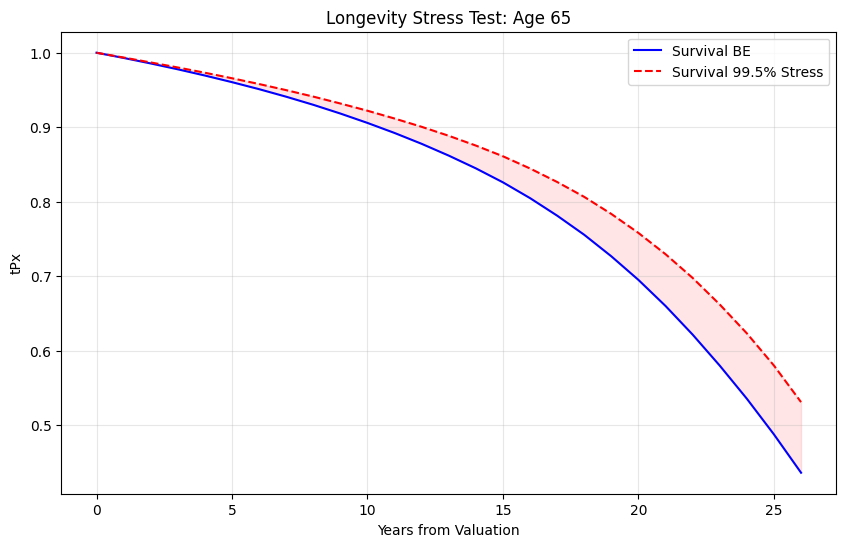

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(surv_be)), surv_be, label='Survival BE', color='blue')
plt.plot(np.arange(len(surv_stress)), surv_stress, 'r--', label='Survival 99.5% Stress')
plt.fill_between(np.arange(len(surv_be)), surv_be, surv_stress, color='red', alpha=0.1)

plt.title(f'Longevity Stress Test: Age {valuation_age}')
plt.xlabel('Years from Valuation'); plt.ylabel('tPx')
plt.grid(alpha=0.3); plt.legend()
plt.savefig('../reports/figures/08_longevity_stress_test.png', dpi=300)
plt.show()

## 5. Actuarial Backtesting (SVD)

In [16]:
split_year = 2010
train_matrix = log_mx.loc[:, :split_year]
test_matrix = log_mx.loc[:, split_year+1:]
test_years = test_matrix.columns

alpha_train = train_matrix.mean(axis=1)
Z_train = train_matrix.sub(alpha_train, axis=0)
U, S, Vh = np.linalg.svd(Z_train, full_matrices=False)
bx_train = U[:, 0] / U[:, 0].sum()
kt_train = Vh[0, :] * S[0] * U[:, 0].sum()
if kt_train[0] < kt_train[-1]: kt_train, bx_train = -kt_train, -bx_train

drift_train = np.mean(np.diff(kt_train))
kt_pred = kt_train[-1] + drift_train * np.arange(1, len(test_years) + 1)

age_sample = 75
actual_log_mx = test_matrix.loc[age_sample, :].values
pred_log_mx = alpha_train[age_sample] + bx_train[age_sample] * kt_pred

rmse = np.sqrt(np.mean((actual_log_mx - pred_log_mx)**2))
print(f"SVD Baseline RMSE: {rmse:.4f}")

SVD Baseline RMSE: 0.1682


## 6. ML Data Preparation

In [17]:
from sklearn.preprocessing import StandardScaler

train_df = df_clean[df_clean['Year'] <= 2010].copy()
X_train = train_df[['Age', 'Year']].values
y_train = np.log(train_df['Total'].values)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_age75 = np.array([[age_sample, y] for y in test_years])
X_test_scaled = scaler.transform(X_test_age75)

print(f"Data scaled. Training on {len(X_train_scaled)} samples.")

Data scaled. Training on 5856 samples.


## 7. Model: Pure MLP

In [18]:
n_iter = 10
nn_preds_all = []

print(f"Starting Pure MLP iterations ({n_iter} runs)...")
for i in range(n_iter):
    model_pure = Sequential([
        Dense(64, activation='relu', input_shape=(2,)),
        Dropout(0.1),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model_pure.compile(optimizer='adam', loss='mse')
    model_pure.fit(X_train_scaled, y_train, epochs=100, batch_size=32, verbose=0)
    
    nn_pred = model_pure.predict(X_test_scaled, verbose=0).flatten()
    nn_preds_all.append(nn_pred)
    print(f" > Progress: {i+1}/{n_iter} completed")

nn_pred_mean = np.mean(nn_preds_all, axis=0)
nn_rmse = np.sqrt(np.mean((actual_log_mx - nn_pred_mean)**2))
print(f"\nMLP Average RMSE: {nn_rmse:.4f}")

Starting Pure MLP iterations (10 runs)...
 > Progress: 1/10 completed
 > Progress: 2/10 completed
 > Progress: 3/10 completed
 > Progress: 4/10 completed
 > Progress: 5/10 completed
 > Progress: 6/10 completed
 > Progress: 7/10 completed
 > Progress: 8/10 completed
 > Progress: 9/10 completed
 > Progress: 10/10 completed

MLP Average RMSE: 0.2090


## 8. Model: Hybrid Residuals

In [19]:
hybrid_preds_all = []
# Pre-calculating residuals for efficiency
log_mx_train = log_mx.loc[:, :split_year]
svd_reco = alpha_train.values.reshape(-1, 1) + (bx_train.reshape(-1, 1) @ kt_train.reshape(1, -1))
res_train = (log_mx_train.values - svd_reco).flatten()

X_res_map = np.array([[age, yr] for yr in train_matrix.columns for age in train_matrix.index])
scaler_res = StandardScaler()
X_res_scaled = scaler_res.fit_transform(X_res_map)
X_test_res_scaled = scaler_res.transform(X_test_age75)

print(f"Starting Hybrid iterations ({n_iter} runs)...")
for i in range(n_iter):
    model_res = Sequential([
        Dense(64, activation='relu', input_shape=(2,)),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model_res.compile(optimizer='adam', loss='mse')
    model_res.fit(X_res_scaled, res_train, epochs=50, batch_size=64, verbose=0)
    
    pred_res = model_res.predict(X_test_res_scaled, verbose=0).flatten()
    hybrid_preds_all.append(pred_log_mx + pred_res)
    print(f" > Progress: {i+1}/{n_iter} completed")

hybrid_pred_mean = np.mean(hybrid_preds_all, axis=0)
hybrid_rmse = np.sqrt(np.mean((actual_log_mx - hybrid_pred_mean)**2))
print(f"\nHybrid Average RMSE: {hybrid_rmse:.4f}")

Starting Hybrid iterations (10 runs)...
 > Progress: 1/10 completed
 > Progress: 2/10 completed
 > Progress: 3/10 completed
 > Progress: 4/10 completed
 > Progress: 5/10 completed
 > Progress: 6/10 completed
 > Progress: 7/10 completed
 > Progress: 8/10 completed
 > Progress: 9/10 completed
 > Progress: 10/10 completed

Hybrid Average RMSE: 0.1454


## 9. Model: LSTM Champion

In [20]:
# --- LSTM Strategy: Sequence Learning (n_iter average) ---
lstm_preds_all = []
kt_train_series = kt_train.reshape(-1, 1)
scaler_lstm = MinMaxScaler(feature_range=(0, 1))
kt_scaled = scaler_lstm.fit_transform(kt_train_series)

# Increased window size to capture a full decade of mortality trends
window_size = 10 

# Sequences are created using the function defined in the Setup cell
X_l, y_l = create_sequences(kt_scaled, window_size)
X_l = X_l.reshape((X_l.shape[0], X_l.shape[1], 1))

print(f"Starting LSTM iterations ({n_iter} runs) with window_size={window_size}...")

for i in range(n_iter):
    # Slightly increased capacity (64 units) to handle the longer temporal window
    model_lstm = Sequential([
        LSTM(64, activation='relu', input_shape=(window_size, 1)),
        Dense(1)
    ])
    model_lstm.compile(optimizer='adam', loss='mse')
    
    # Increased epochs to 150 to ensure convergence with longer sequences
    model_lstm.fit(X_l, y_l, epochs=150, verbose=0)

    # Recursive multi-step forecasting for the test period
    curr_batch = kt_scaled[-window_size:].reshape((1, window_size, 1))
    kt_p_scaled = []
    
    for _ in range(len(test_years)):
        # Predict next value and update the sliding window
        next_v = model_lstm.predict(curr_batch, verbose=0)[0, 0]
        kt_p_scaled.append(next_v)
        
        # Shift window: remove first element and append the new prediction
        next_v_reshaped = np.array(next_v).reshape(1, 1, 1)
        curr_batch = np.append(curr_batch[:, 1:, :], next_v_reshaped, axis=1)

    # Invert scaling and project back to mortality space
    kt_p = scaler_lstm.inverse_transform(np.array(kt_p_scaled).reshape(-1, 1)).flatten()
    lstm_preds_all.append(alpha_train[age_sample] + bx_train[age_sample] * kt_p)
    
    print(f" > Progress: {i+1}/{n_iter} completed")

# Final metric calculation using the mean of all iterations
lstm_pred_mean = np.mean(lstm_preds_all, axis=0)
lstm_rmse = np.sqrt(np.mean((actual_log_mx - lstm_pred_mean)**2))

print(f"\nLSTM Average RMSE (window={window_size}): {lstm_rmse:.4f}")

Starting LSTM iterations (10 runs) with window_size=10...
 > Progress: 1/10 completed
 > Progress: 2/10 completed
 > Progress: 3/10 completed
 > Progress: 4/10 completed
 > Progress: 5/10 completed
 > Progress: 6/10 completed
 > Progress: 7/10 completed
 > Progress: 8/10 completed
 > Progress: 9/10 completed
 > Progress: 10/10 completed

LSTM Average RMSE (window=10): 0.1115


## 10. Plot: Final Comparison

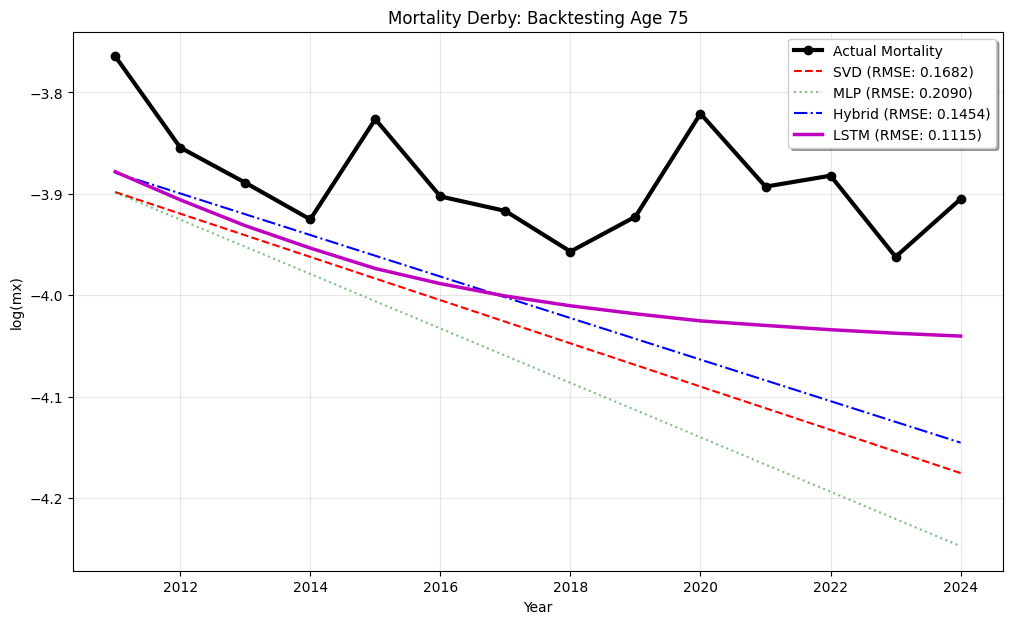

In [21]:
plt.figure(figsize=(12, 7))
plt.plot(test_years, actual_log_mx, 'ko-', label='Actual Mortality', linewidth=3)
plt.plot(test_years, pred_log_mx, 'r--', label=f'SVD (RMSE: {rmse:.4f})')
plt.plot(test_years, nn_pred_mean, 'g:', label=f'MLP (RMSE: {nn_rmse:.4f})', alpha=0.5)
plt.plot(test_years, hybrid_pred_mean, 'b-.', label=f'Hybrid (RMSE: {hybrid_rmse:.4f})')
plt.plot(test_years, lstm_pred_mean, 'm-', label=f'LSTM (RMSE: {lstm_rmse:.4f})', linewidth=2.5)

plt.title(f'Mortality Derby: Backtesting Age {age_sample}')
plt.xlabel('Year'); plt.ylabel('log(mx)')
plt.legend(frameon=True, shadow=True); plt.grid(alpha=0.3)
plt.savefig('../reports/figures/09_final_comparison.png', dpi=300)
plt.show()